In [40]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from src.optimizer import optimize_arm
import os
import sys

sys.path.append(os.path.abspath(".."))
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir = os.path.join(project_root, "outputs", "regression")
os.makedirs(output_dir, exist_ok=True)
print("Output path set to:", output_dir)

Output path set to: /Users/amit/Documents/smt/DS623-Optimotion/outputs/regression


In [41]:
def generate_dataset_with_optimization(link1_length, link2_length, num_points=100, num_instances=100, learning_rate=0.1, iterations=50):
    max_reach = link1_length + link2_length
    x_range = (0, max_reach)
    y_range = (0, max_reach)

    # Adjust step size if not provided
    step_x = (x_range[1] - x_range[0]) / num_instances
    step_y = (y_range[1] - y_range[0]) / num_instances
    step = min(step_x, step_y)

    data = []
    targets = []

    for x in np.arange(x_range[0], x_range[1], step):
        for y in np.arange(y_range[0], y_range[1], step):
            # Initial guesses for theta1 and theta2
            theta1_init = np.radians(20)
            theta2_init = np.radians(10)

            # Use the optimization function to find angles θ1, θ2 for the target (x, y)
            _, _, history = optimize_arm(
                theta1_init, theta2_init,
                x, y,
                learning_rate=learning_rate,
                iterations=iterations,
                verbose=False
            )

            # The last entry of history contains the final cost and angles
            final_theta1, final_theta2, _ = history[-1]
            # data.append([x, y])  # (x, y) as input features
            # Use with interaction term for better prediction
            data.append([x, y, x * y])  # (x, y) and interaction term (x * y)

            targets.append([np.degrees(final_theta1), np.degrees(final_theta2)])  # Angles in degrees as target

    input_instances = np.array(data)
    targets = np.array(targets)

    return input_instances, targets

In [42]:
# Generate dataset with optimization
input_instances_optimized, targets_optimized = generate_dataset_with_optimization(link1_length=10.0, link2_length=10.0, num_instances=100)

# Split into train and test datasets (80% train, 20% test)
training_input_instances, testing_input_instances, training_targets, testing_targets = train_test_split(X_optimized, y_optimized, test_size=0.2, random_state=42)

Simple Linear Regression (θ1 R² score): 0.866837891463292
Simple Linear Regression (θ2 R² score): 0.06626521469383284


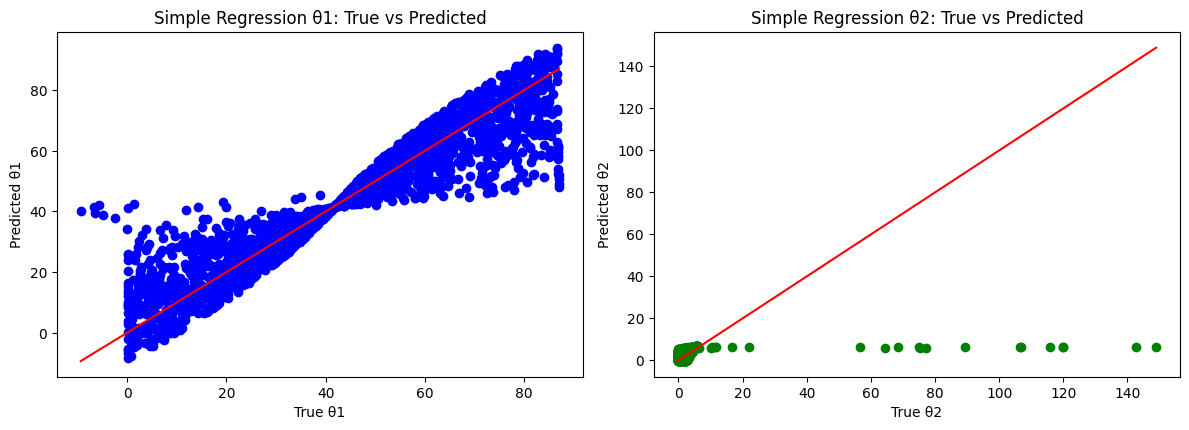

In [43]:
# ==========================
# 1. Simple Two Separate Linear Regression Models for theta1 and theta2
# ==========================
# Create two separate linear regression models for θ1 and θ2
regressor_theta1 = LinearRegression()
regressor_theta2 = LinearRegression()

# Fit the models
regressor_theta1.fit(training_input_instances, training_targets[:, 0])  # Fit for θ1
regressor_theta2.fit(training_input_instances, training_targets[:, 1])  # Fit for θ2

# Predictions on the test set
theta1_pred_simple = regressor_theta1.predict(testing_input_instances)
theta2_pred_simple = regressor_theta2.predict(testing_input_instances)

# ==========================
# R² Score Evaluation
# ==========================
# Simple Regression R²
print("Simple Linear Regression (θ1 R² score):", r2_score(y_test[:, 0], theta1_pred_simple))
print("Simple Linear Regression (θ2 R² score):", r2_score(y_test[:, 1], theta2_pred_simple))


# ==========================
# Plotting Results
# ==========================
plt.figure(figsize=(12, 8))

# Plot for θ1 predictions (Simple Regression)
plt.subplot(2, 2, 1)
plt.scatter(y_test[:, 0], theta1_pred_simple, label="Simple Regression", color='blue')
plt.plot([min(y_test[:, 0]), max(y_test[:, 0])], [min(y_test[:, 0]), max(y_test[:, 0])], color='red')
plt.xlabel('True θ1')
plt.ylabel('Predicted θ1')
plt.title('Simple Regression θ1: True vs Predicted')

# Plot for θ2 predictions (Simple Regression)
plt.subplot(2, 2, 2)
plt.scatter(y_test[:, 1], theta2_pred_simple, label="Simple Regression", color='green')
plt.plot([min(y_test[:, 1]), max(y_test[:, 1])], [min(y_test[:, 1]), max(y_test[:, 1])], color='red')
plt.xlabel('True θ2')
plt.ylabel('Predicted θ2')
plt.title('Simple Regression θ2: True vs Predicted')

plt.tight_layout()
plt.savefig(f"{output_dir}/simple_linear_regression_performance.png")
plt.show()
plt.close()

Multivariate Linear Regression (θ1 and θ2 R² score): 0.466551553078563


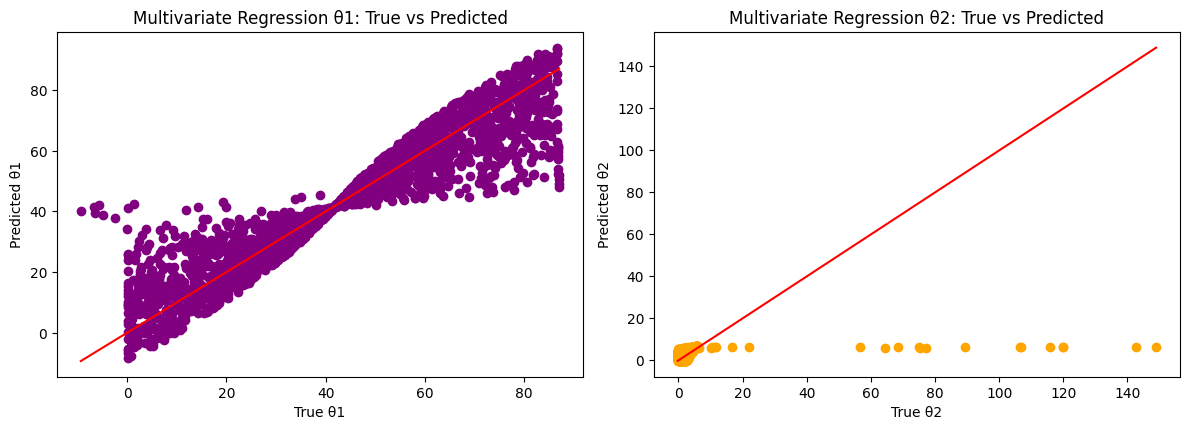

In [44]:
# ==========================
# 2. Multivariate Linear Regression
# ==========================
# Train a single multivariate regression model for both theta1 and theta2
regressor_multivariate = LinearRegression()

# Fit the model for both θ1 and θ2 (predicting both simultaneously)
regressor_multivariate.fit(X_train, y_train)

# Predictions on the test set for multivariate regression
y_pred_multivariate = regressor_multivariate.predict(X_test)
theta1_pred_multivariate = y_pred_multivariate[:, 0]
theta2_pred_multivariate = y_pred_multivariate[:, 1]

# Multivariate Regression R²
print("Multivariate Linear Regression (θ1 and θ2 R² score):", r2_score(y_test, y_pred_multivariate))


# ==========================
# Plotting Results
# ==========================
plt.figure(figsize=(12, 8))

# Plot for multivariate θ1 predictions (Multivariate Regression)
plt.subplot(2, 2, 3)
plt.scatter(y_test[:, 0], theta1_pred_multivariate, label="Multivariate Regression", color='purple')
plt.plot([min(y_test[:, 0]), max(y_test[:, 0])], [min(y_test[:, 0]), max(y_test[:, 0])], color='red')
plt.xlabel('True θ1')
plt.ylabel('Predicted θ1')
plt.title('Multivariate Regression θ1: True vs Predicted')

# Plot for multivariate θ2 predictions (Multivariate Regression)
plt.subplot(2, 2, 4)
plt.scatter(y_test[:, 1], theta2_pred_multivariate, label="Multivariate Regression", color='orange')
plt.plot([min(y_test[:, 1]), max(y_test[:, 1])], [min(y_test[:, 1]), max(y_test[:, 1])], color='red')
plt.xlabel('True θ2')
plt.ylabel('Predicted θ2')
plt.title('Multivariate Regression θ2: True vs Predicted')

plt.tight_layout()
plt.savefig(f"{output_dir}/multivariate_linear_regression_performance.png")
plt.show()
plt.close()
